# Non-Linear Variable Relationships in Census Data

This notebook investigates pairwise relationships between 408 census variables using:
- **Spearman correlation** (rank-based, captures monotonic non-linear relationships)
- **Pearson correlation** as linear baseline
- Focus on "purely non-linear" relationships (high |Spearman|, low |Pearson|)

**Why Spearman vs Pearson?**
- When |Spearman| >> |Pearson|, indicates a **monotonic non-linear relationship** (e.g., exponential, logarithmic)
- Both correlations are computed via fast vectorized operations (~30 seconds total)
- Alternative to Mutual Information which takes 2-4 hours

**Analysis Pipeline:**
1. Compute pairwise Spearman and Pearson correlations for all variable pairs
2. Identify relationships with high |Spearman| but low |Pearson|
3. Visualize top-k most non-linear relationships with scatter plots and fitted curves

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr
from scipy.optimize import curve_fit
import pickle

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

# Font and style setup
import matplotlib.font_manager as fm

# Try to load Montserrat; fall back to default if not installed
montserrat_paths = fm.findSystemFonts(fontpaths=None)
montserrat_found = [p for p in montserrat_paths if 'ontserrat' in p.lower()]
if montserrat_found:
    for fp in montserrat_found:
        fm.fontManager.addfont(fp)
    plt.rcParams['font.family'] = 'Montserrat'
    print(f"Montserrat loaded ({len(montserrat_found)} variants)")
else:
    print("WARNING: Montserrat not found on system. Install it or add the .ttf files.")
    plt.rcParams['font.family'] = 'sans-serif'

# Transparent backgrounds
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

Montserrat loaded (2 variants)


## 2. Configuration

In [3]:
# Random seed for reproducibility
random_seed = 20210321
np.random.seed(random_seed)

# Paths
cleaned_data_path = "../../data/census_data/engcensus_cleaned_scaled.parquet"
category_path = "../../data/census_data/Category.csv"

# Output directories
output_dir = "../plots/nonlinear_relationships/"
cache_dir = "../../data/cache/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data/", exist_ok=True)
os.makedirs(cache_dir, exist_ok=True)

# Analysis parameters
use_cache = True  # Set to False to force recomputation
n_top_relationships = 50  # Top-k relationships to visualize
subsample_for_plots = 10000  # Subsample OAs for scatter plots to reduce clutter
pearson_threshold = 0.3  # Low linear correlation threshold

print(f"Configuration:")
print(f"  Random seed: {random_seed}")
print(f"  Use cache: {use_cache}")
print(f"  Top relationships to visualize: {n_top_relationships}")
print(f"  Output directory: {output_dir}")
print(f"  Pearson threshold: {pearson_threshold}")

Configuration:
  Random seed: 20210321
  Use cache: True
  Top relationships to visualize: 50
  Output directory: ../plots/nonlinear_relationships/
  Pearson threshold: 0.3


## 3. Load and Prepare Data

In [4]:
# Load census data
df = pd.read_parquet(cleaned_data_path)
df = df.set_index('OA')
print(f"Census data: {df.shape}")
print(f"Variables: {len(df.columns)}")
print(f"Output Areas: {len(df)}")

# Load category mapping
categories = pd.read_csv(category_path)
print(f"\nCategory mapping loaded: {len(categories)} tables")

# Create variable-to-category mapping
var_to_category = {}
for var in df.columns:
    prefix = var[:5]  # e.g., 'ts001', 'ts002'
    matching_cat = categories[categories['Table'] == prefix]
    if len(matching_cat) > 0:
        var_to_category[var] = matching_cat['Category'].values[0]
    else:
        var_to_category[var] = 'Unknown'

# Print category distribution
cat_counts = pd.Series(var_to_category).value_counts()
print(f"\nVariables by category:")
print(cat_counts)

# Load human-readable variable names
var_meta = pd.read_csv("../../data/census_data/Variable_Metadata.csv")
var_id_to_name = dict(zip(var_meta['Variable_ID'], var_meta['Variable_Name']))
print(f"Variable name mapping loaded: {len(var_id_to_name)} entries")

def pct_label(var_id):
    """Return '% Human Name' for axis labels."""
    name = var_id_to_name.get(var_id, var_id)
    # Strip leading table/total prefix if present
    if ': ' in name:
        name = name.split(': ', 1)[1]
    return f'% {name}'

Census data: (188880, 408)
Variables: 408
Output Areas: 188880

Category mapping loaded: 77 tables

Variables by category:
Demography and migration                      159
Ethnicity, Identity, Language and Religion     78
Work and Travel                                78
Housing                                        62
Health                                         22
Education                                       9
Name: count, dtype: int64
Variable name mapping loaded: 488 entries


## 4. Compute Pairwise Metrics (Fast Method)

This section computes:
1. **Pearson correlation** (linear relationship) - vectorized, fast
2. **Spearman correlation** (rank-based, captures monotonic non-linear) - vectorized, fast
3. **Non-linearity score** = |Spearman| - |Pearson|

**Why this is fast**: Both Pearson and Spearman can be computed in a single vectorized operation (~30 seconds total).

Results are cached to avoid recomputation.

In [5]:
cache_file = f"{cache_dir}/pairwise_metrics_spearman.parquet"

if use_cache and os.path.exists(cache_file):
    print(f"Loading cached pairwise metrics from {cache_file}")
    pairwise_df = pd.read_parquet(cache_file)
    print(f"Loaded {len(pairwise_df)} pairwise relationships")
else:
    print("Computing pairwise metrics (Spearman vs Pearson)...")
    
    # STEP 1: Filter out constant/near-constant variables
    var_variance = df.var()
    valid_vars = var_variance[var_variance > 1e-6].index.tolist()
    df_filtered = df[valid_vars]
    print(f"Filtered to {len(valid_vars)} variables (removed {len(df.columns) - len(valid_vars)} constant variables)")
    
    # STEP 2: Compute Pearson correlation matrix (vectorized - FAST)
    print("\nComputing Pearson correlation matrix...")
    pearson_matrix = df_filtered.corr(method='pearson')
    print(f"Pearson correlation matrix: {pearson_matrix.shape}")
    
    # STEP 3: Compute Spearman correlation matrix (vectorized - FAST)
    print("Computing Spearman correlation matrix...")
    spearman_matrix = df_filtered.corr(method='spearman')
    print(f"Spearman correlation matrix: {spearman_matrix.shape}")
    
    # STEP 4: Extract upper triangle and create pairwise DataFrame
    print("\nCreating pairwise relationship DataFrame...")
    relationships = []
    
    for i in range(len(valid_vars)):
        for j in range(i + 1, len(valid_vars)):
            var1 = valid_vars[i]
            var2 = valid_vars[j]
            
            pearson_r = pearson_matrix.iloc[i, j]
            spearman_r = spearman_matrix.iloc[i, j]
            
            relationships.append({
                'var1': var1,
                'var2': var2,
                'var1_category': var_to_category.get(var1, 'Unknown'),
                'var2_category': var_to_category.get(var2, 'Unknown'),
                'pearson_r': pearson_r,
                'spearman_r': spearman_r,
                'pearson_r_abs': abs(pearson_r),
                'spearman_r_abs': abs(spearman_r),
            })
    
    pairwise_df = pd.DataFrame(relationships)
    
    # STEP 5: Compute non-linearity score
    # |Spearman| > |Pearson| indicates monotonic non-linear relationship
    pairwise_df['nonlinearity_score'] = pairwise_df['spearman_r_abs'] - pairwise_df['pearson_r_abs']
    
    # Save to cache
    pairwise_df.to_parquet(cache_file)
    print(f"\nSaved {len(pairwise_df)} pairwise relationships to {cache_file}")

print(f"\nPairwise metrics computed:")
print(f"  Total pairs: {len(pairwise_df)}")
print(f"  Pearson |r| range: [{pairwise_df['pearson_r_abs'].min():.4f}, {pairwise_df['pearson_r_abs'].max():.4f}]")
print(f"  Spearman |r| range: [{pairwise_df['spearman_r_abs'].min():.4f}, {pairwise_df['spearman_r_abs'].max():.4f}]")
print(f"  Non-linearity score range: [{pairwise_df['nonlinearity_score'].min():.4f}, {pairwise_df['nonlinearity_score'].max():.4f}]")

Loading cached pairwise metrics from ../../data/cache//pairwise_metrics_spearman.parquet
Loaded 79401 pairwise relationships

Pairwise metrics computed:
  Total pairs: 79401
  Pearson |r| range: [0.0000, 1.0000]
  Spearman |r| range: [0.0000, 1.0000]
  Non-linearity score range: [-0.7343, 0.3419]


## 5. Filter and Rank Non-Linear Relationships

Identify "purely non-linear" relationships:
- High |Spearman| (strong monotonic relationship)
- Low |Pearson| (weak linear relationship)
- Positive non-linearity score (|Spearman| > |Pearson|)

In [6]:
# Filter for visually clear non-linear relationships
# Key insight: many census variables are sparse proportions with lots of zeros,
# which makes scatter plots look like blobs at the origin. We filter these out.

# Compute per-variable quality metrics
zero_frac = (df == 0).sum() / len(df)
max_zero_frac = 0.20  # both variables must have <20% zeros
good_vars = set(zero_frac[zero_frac < max_zero_frac].index)
print(f"Variables with <{max_zero_frac:.0%} zeros: {len(good_vars)} / {len(df.columns)}")

# Filter criteria for talk-quality plots:
# 1. Both variables well-spread (few zeros, good range)
# 2. Strong Spearman (>0.4) so relationship is visible
# 3. Meaningful non-linearity gap (>0.1)
nonlinear_candidates = pairwise_df[
    (pairwise_df['var1'].isin(good_vars)) &
    (pairwise_df['var2'].isin(good_vars)) &
    (pairwise_df['spearman_r_abs'] > 0.4) &
    (pairwise_df['nonlinearity_score'] > 0.1)
].copy()

# Flag cross-category pairs (more interesting for a talk)
nonlinear_candidates['cross_category'] = nonlinear_candidates.apply(
    lambda r: var_to_category.get(r['var1'], '') != var_to_category.get(r['var2'], ''), axis=1
)

# Sort: cross-category first, then by non-linearity score
nonlinear_candidates = nonlinear_candidates.sort_values(
    ['cross_category', 'nonlinearity_score'], ascending=[False, False]
)

# Select top-k for visualization
top_nonlinear = nonlinear_candidates.head(n_top_relationships)

print(f"\nFiltering for visually clear non-linear relationships:")
print(f"  Found: {len(nonlinear_candidates)} candidate pairs ({nonlinear_candidates['cross_category'].sum()} cross-category)")
print(f"\nTop {min(n_top_relationships, len(top_nonlinear))} relationships:")
print(top_nonlinear[['var1', 'var2', 'spearman_r', 'pearson_r', 'nonlinearity_score', 'cross_category']].head(20).to_string())

# Save results
top_nonlinear.to_csv(f"{output_dir}/data/top_nonlinear_relationships.csv", index=False)
nonlinear_candidates.to_csv(f"{output_dir}/data/all_nonlinear_candidates.csv", index=False)
pairwise_df.to_csv(f"{output_dir}/data/all_pairwise_metrics.csv", index=False)
print(f"\nResults saved to {output_dir}/data/")

Variables with <20% zeros: 240 / 408

Filtering for visually clear non-linear relationships:
  Found: 365 candidate pairs (257 cross-category)

Top 50 relationships:
             var1       var2  spearman_r  pearson_r  nonlinearity_score  cross_category
18090   ts0040011  ts0210012    0.547274   0.308743            0.238531            True
31084  ts007a0006  ts0520005    0.415991   0.179991            0.236000            True
15609   ts0040004  ts0210002    0.541931   0.306251            0.235680            True
15965   ts0040005  ts0210002    0.468666   0.235284            0.233382            True
69185   ts0450002  ts0620002   -0.458687  -0.231465            0.227221            True
30253  ts007a0003  ts0680003   -0.679670  -0.458618            0.221052            True
30252  ts007a0003  ts0680002    0.679670   0.458618            0.221052            True
18107   ts0040011  ts0230005    0.485212   0.265119            0.220093            True
30565  ts007a0004  ts0680002    0.710276  

## 6. Overview Visualizations

### 6.1 Spearman vs Pearson Scatter Plot

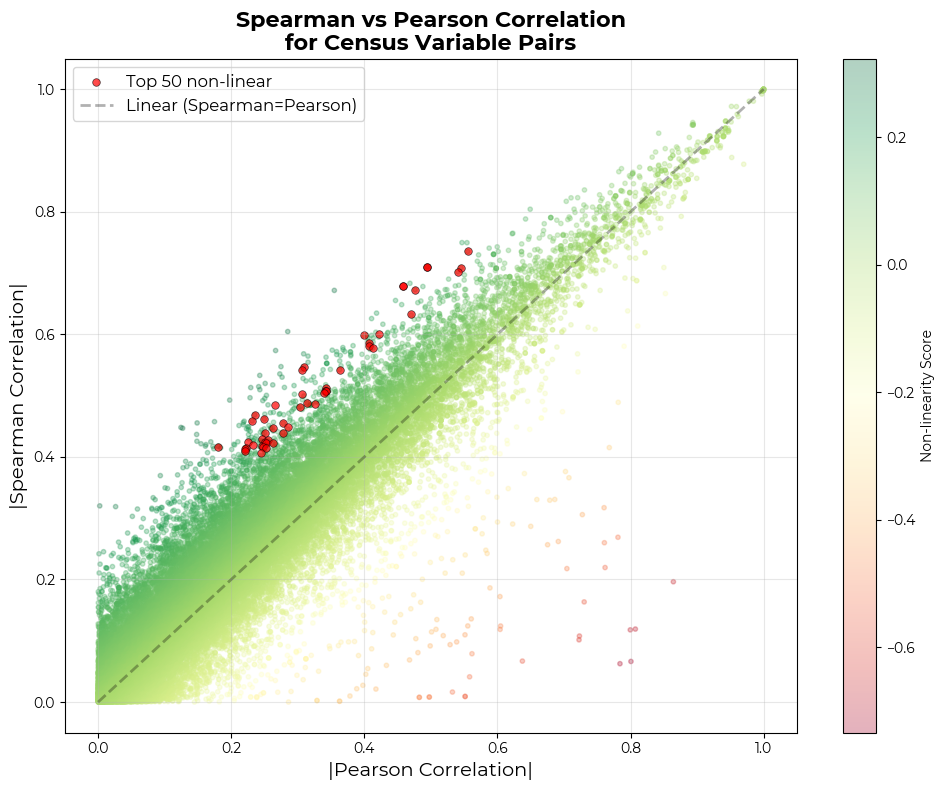

In [7]:
# Scatter plot: |Spearman| vs |Pearson| for all pairs
fig, ax = plt.subplots(figsize=(10, 8))

# Sample for visualization if too many points
if len(pairwise_df) > 50000:
    plot_df = pairwise_df.sample(n=50000, random_state=random_seed)
else:
    plot_df = pairwise_df

scatter = ax.scatter(
    plot_df['pearson_r_abs'], 
    plot_df['spearman_r_abs'],
    c=plot_df['nonlinearity_score'],
    cmap='RdYlGn',
    alpha=0.3,
    s=10
)

# Highlight top non-linear relationships
ax.scatter(
    top_nonlinear['pearson_r_abs'],
    top_nonlinear['spearman_r_abs'],
    color='red',
    s=30,
    alpha=0.7,
    label=f'Top {len(top_nonlinear)} non-linear',
    edgecolors='black',
    linewidths=0.5
)

# Add diagonal line (Spearman = Pearson means linear)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Linear (Spearman=Pearson)')

ax.set_xlabel('|Pearson Correlation|', fontsize=14)
ax.set_ylabel('|Spearman Correlation|', fontsize=14)
ax.set_title('Spearman vs Pearson Correlation\nfor Census Variable Pairs', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.colorbar(scatter, ax=ax, label='Non-linearity Score')
plt.tight_layout()
plt.savefig(f"{output_dir}/spearman_vs_pearson_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Category-Based Heatmap

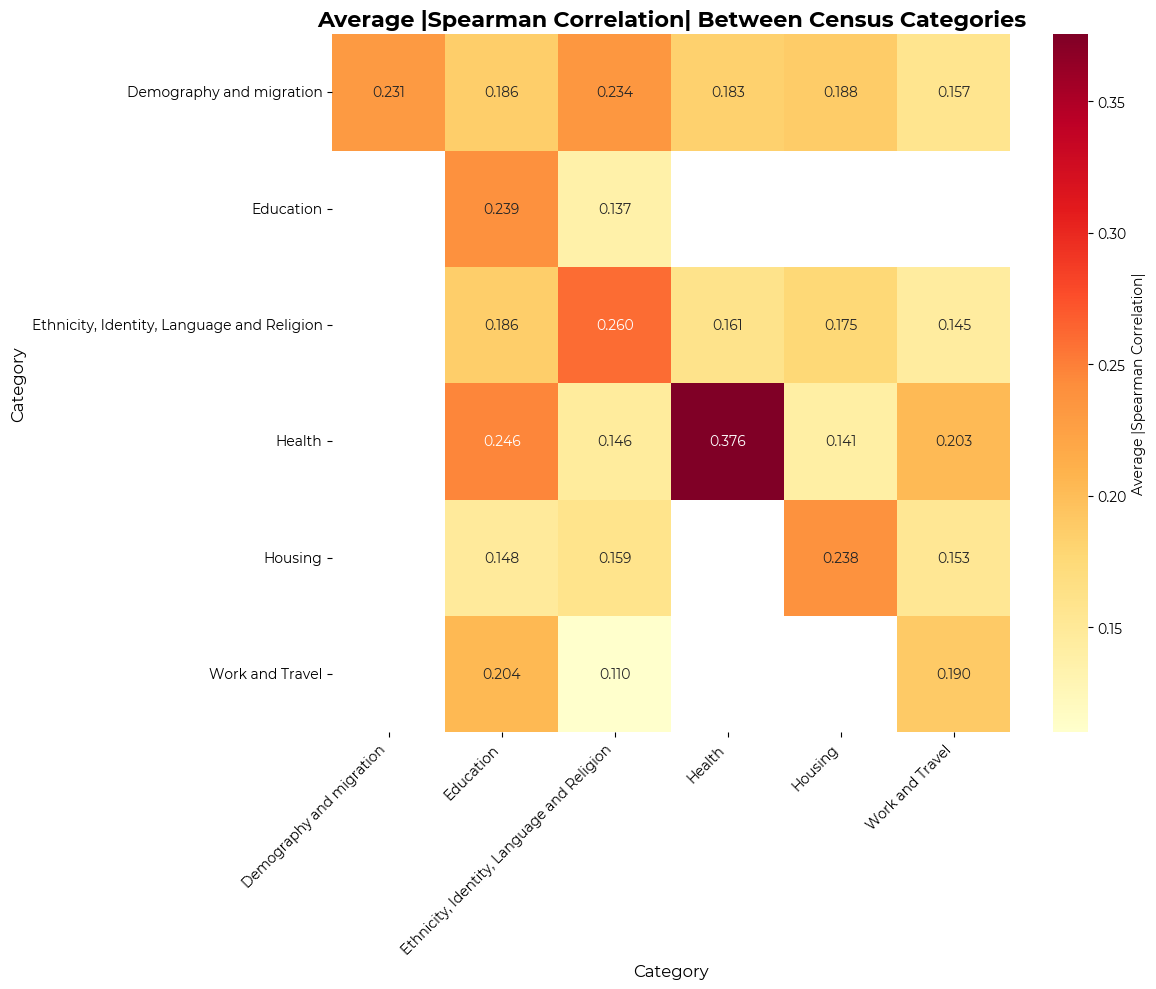

In [8]:
# Heatmap: Average |Spearman| by variable category pairs
category_spearman = pairwise_df.groupby(['var1_category', 'var2_category'])['spearman_r_abs'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    category_spearman, 
    annot=True, 
    fmt='.3f', 
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Average |Spearman Correlation|'}
)
ax.set_title('Average |Spearman Correlation| Between Census Categories', fontsize=16, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/category_spearman_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### 6.3 Distribution Plots

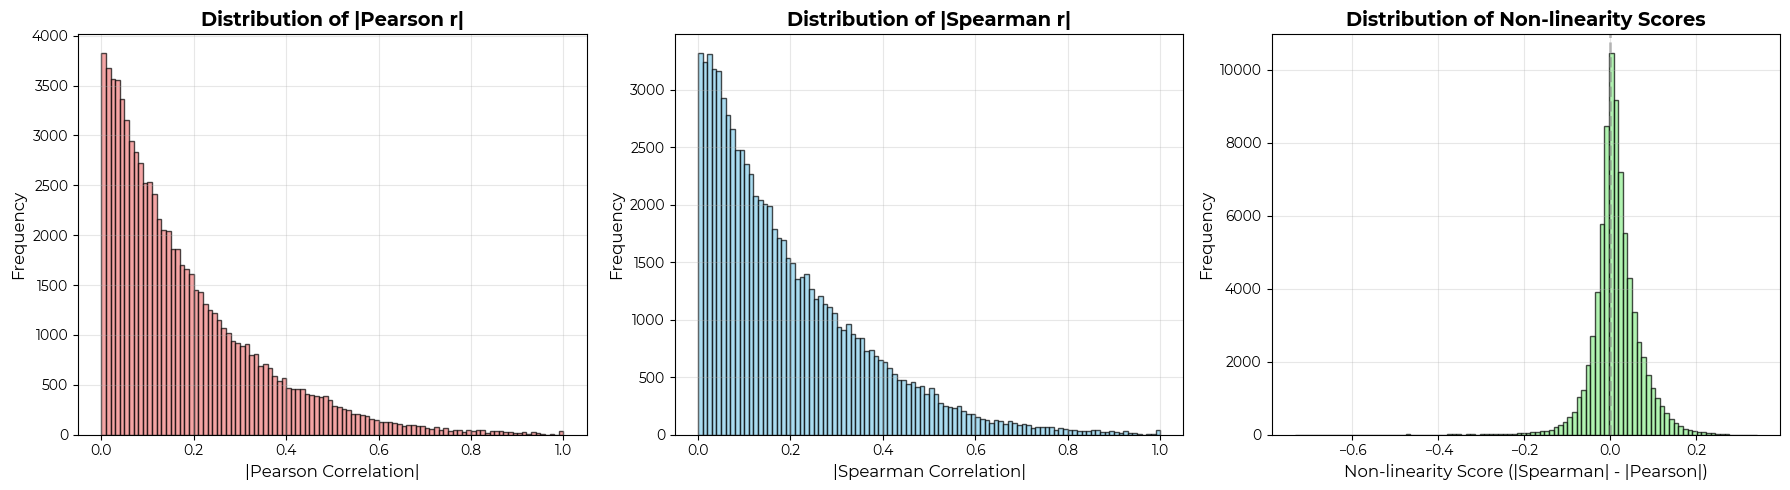

In [9]:
# Distribution of Pearson, Spearman, and Non-linearity scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(pairwise_df['pearson_r_abs'], bins=100, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('|Pearson Correlation|', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of |Pearson r|', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(pairwise_df['spearman_r_abs'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('|Spearman Correlation|', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of |Spearman r|', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].hist(pairwise_df['nonlinearity_score'], bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='gray', linestyle='--', linewidth=2, alpha=0.5)
axes[2].set_xlabel('Non-linearity Score (|Spearman| - |Pearson|)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Distribution of Non-linearity Scores', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/distribution_plots.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Top-K Relationship Scatter Plots

Visualize the top non-linear relationships with scatter plots and polynomial curve fits.

## 7a. Types of Non-Linearity in Census Data

Five distinct types of non-linear relationship found in the census variables, each with a clear substantive interpretation.

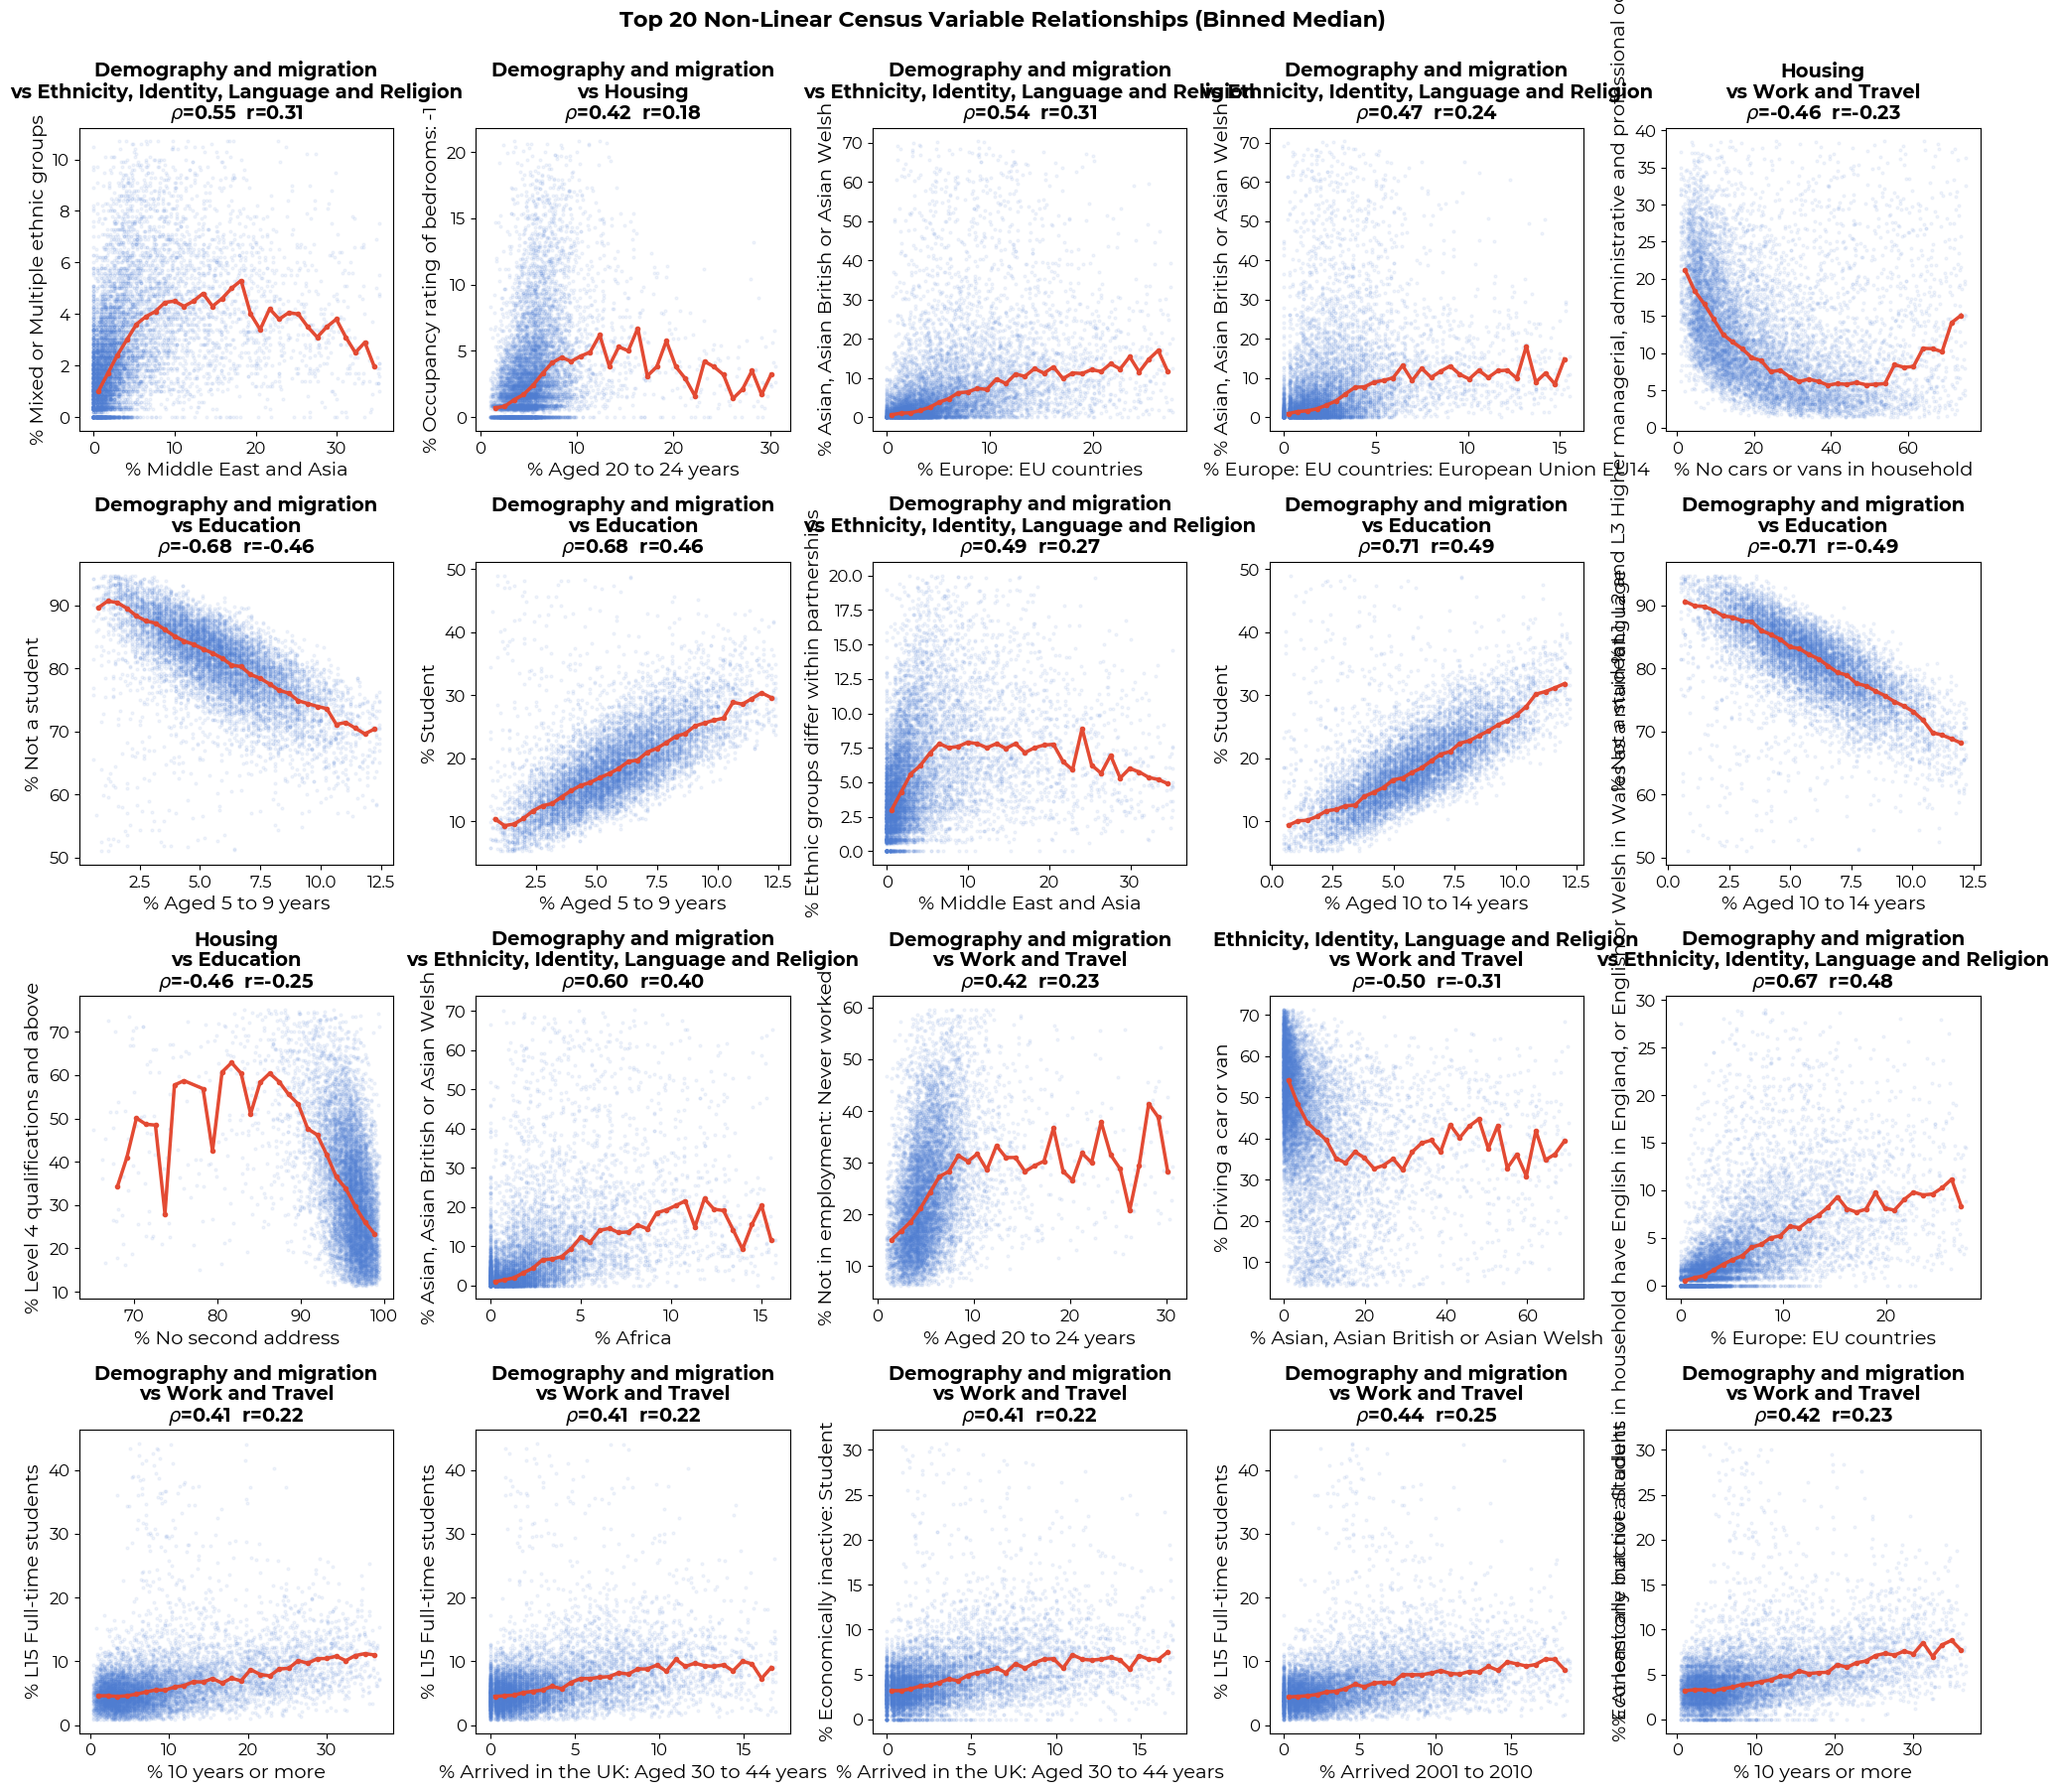

In [10]:
def fit_and_plot_nonlinear(var1, var2, data, ax, rank):
    """Scatter plot with binned median for non-linear relationships."""
    if len(data) > subsample_for_plots:
        plot_data = data.sample(n=subsample_for_plots, random_state=random_seed)
    else:
        plot_data = data

    x = plot_data[var1].values
    y = plot_data[var2].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    # Clip to 1st–99th percentile to remove outlier distortion
    xlo, xhi = np.percentile(x, [1, 99])
    ylo, yhi = np.percentile(y, [1, 99])
    clip = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    x_clip, y_clip = x[clip], y[clip]

    x_clip, y_clip = x_clip * 100, y_clip * 100

    ax.scatter(x_clip, y_clip, alpha=0.08, s=4, color='#4878cf', rasterized=True)

    # Binned median
    n_bins = 30
    bin_edges = np.linspace(x_clip.min(), x_clip.max(), n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_idx = np.digitize(x_clip, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    bin_medians = []
    valid_centers = []
    for b in range(n_bins):
        vals = y_clip[bin_idx == b]
        if len(vals) >= 5:
            bin_medians.append(np.median(vals))
            valid_centers.append(bin_centers[b])

    ax.plot(valid_centers, bin_medians, color='#e34a33', linewidth=2.5, marker='o', markersize=3)

    row = top_nonlinear[(top_nonlinear['var1'] == var1) & (top_nonlinear['var2'] == var2)].iloc[0]
    cat1 = var_to_category.get(var1, '')
    cat2 = var_to_category.get(var2, '')
    ax.set_xlabel(pct_label(var1), fontsize=14)
    ax.set_ylabel(pct_label(var2), fontsize=14)
    ax.set_title(
        f'{cat1}\nvs {cat2}\n'
        f'$\\rho$={row.spearman_r:.2f}  r={row.pearson_r:.2f}',
        fontsize=14, fontweight='bold', linespacing=1.1
    )
    ax.tick_params(labelsize=12)

# Reduce to 20 for a cleaner grid
n_show = min(20, len(top_nonlinear))
n_cols = 5
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.5 * n_rows))
axes = axes.flatten()

for rank, (idx, row) in enumerate(top_nonlinear.head(n_show).iterrows(), 1):
    fit_and_plot_nonlinear(row['var1'], row['var2'], df, axes[rank - 1], rank)

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Top {n_show} Non-Linear Census Variable Relationships (Binned Median)',
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(f"{output_dir}/top_nonlinear_scatterplots.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## 8. Summary Statistics and Report

In [11]:
print("="*80)
print("NON-LINEAR RELATIONSHIP ANALYSIS SUMMARY")
print("="*80)

print(f"\nDataset:")
print(f"  Variables analyzed: {len(df.columns)}")
print(f"  Output Areas: {len(df)}")
print(f"  Total pairwise relationships: {len(pairwise_df)}")

print(f"\nSpearman Correlation Statistics:")
print(f"  Mean |Spearman|: {pairwise_df['spearman_r_abs'].mean():.4f}")
print(f"  Std |Spearman|: {pairwise_df['spearman_r_abs'].std():.4f}")

print(f"\nPearson Correlation Statistics:")
print(f"  Mean |r|: {pairwise_df['pearson_r_abs'].mean():.4f}")
print(f"  Std |r|: {pairwise_df['pearson_r_abs'].std():.4f}")

print(f"\nNon-Linear Relationships:")
print(f"  Candidates (well-spread, |Spearman|>0.4, NL>0.1): {len(nonlinear_candidates)}")
print(f"  Cross-category pairs: {nonlinear_candidates['cross_category'].sum()}")

print(f"\nTop 10 Most Non-Linear Pairs:")
for idx, row in enumerate(top_nonlinear.head(10).itertuples(), 1):
    print(f"  {idx}. {row.var1} ↔ {row.var2}")
    print(f"      ρ={row.spearman_r:.3f}, r={row.pearson_r:.3f}, NL_score={row.nonlinearity_score:.3f}")

print(f"\nCategory Pairs with Highest Average |Spearman|:")
top_cat_pairs = pairwise_df.groupby(['var1_category', 'var2_category'])['spearman_r_abs'].mean().nlargest(5)
for (cat1, cat2), spearman in top_cat_pairs.items():
    print(f"  {cat1} ↔ {cat2}: {spearman:.3f}")

print("\n" + "="*80)
print(f"Analysis complete! Outputs saved to: {output_dir}")
print("="*80)

NON-LINEAR RELATIONSHIP ANALYSIS SUMMARY

Dataset:
  Variables analyzed: 408
  Output Areas: 188880
  Total pairwise relationships: 79401

Spearman Correlation Statistics:
  Mean |Spearman|: 0.1936
  Std |Spearman|: 0.1684

Pearson Correlation Statistics:
  Mean |r|: 0.1800
  Std |r|: 0.1637

Non-Linear Relationships:
  Candidates (well-spread, |Spearman|>0.4, NL>0.1): 365
  Cross-category pairs: 257

Top 10 Most Non-Linear Pairs:
  1. ts0040011 ↔ ts0210012
      ρ=0.547, r=0.309, NL_score=0.239
  2. ts007a0006 ↔ ts0520005
      ρ=0.416, r=0.180, NL_score=0.236
  3. ts0040004 ↔ ts0210002
      ρ=0.542, r=0.306, NL_score=0.236
  4. ts0040005 ↔ ts0210002
      ρ=0.469, r=0.235, NL_score=0.233
  5. ts0450002 ↔ ts0620002
      ρ=-0.459, r=-0.231, NL_score=0.227
  6. ts007a0003 ↔ ts0680003
      ρ=-0.680, r=-0.459, NL_score=0.221
  7. ts007a0003 ↔ ts0680002
      ρ=0.680, r=0.459, NL_score=0.221
  8. ts0040011 ↔ ts0230005
      ρ=0.485, r=0.265, NL_score=0.220
  9. ts007a0004 ↔ ts0680002
  

In [12]:
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess
from scipy.stats import spearmanr, pearsonr, gaussian_kde

# Five types of non-linearity found in the census data
nonlinearity_types = [
    ('ts0510006', 'ts0520002',
     '(a) Saturation / Ceiling',
     '% Overcrowded', '% Owned outright'),
    ('ts0250003', 'ts0290004',
     '(b) Concentration / Hockey Stick',
     '% Mixed ethnicity', '% Non-English main language'),
    ('ts0450002', 'ts0620002',
     '(c) Threshold',
     '% One-person households', '% Managers & professionals'),
    ('ts007a0004', 'ts0680002',
     '(d) Diminishing Returns',
     '% Aged 22-24', '% Schoolchildren'),
    ('ts0670007', 'ts0450002',
     '(e) U-shaped',
     '% With degree', '% One-person households'),
]

def _clip(x, y, lo=1, hi=99):
    """Clip both arrays to shared percentile range."""
    xlo, xhi = np.percentile(x, [lo, hi])
    ylo, yhi = np.percentile(y, [lo, hi])
    mask = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    return x[mask], y[mask]

def _binned_stats(x, y, n_bins=30):
    """Quantile-binned means and IQR."""
    bin_edges = np.unique(np.percentile(x, np.linspace(0, 100, n_bins + 1)))
    n = len(bin_edges) - 1
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(x, bin_edges) - 1, 0, n - 1)
    means, q25, q75 = [], [], []
    for b in range(n):
        vals = y[idx == b]
        if len(vals) > 10:
            means.append(vals.mean())
            q25.append(np.percentile(vals, 25))
            q75.append(np.percentile(vals, 75))
        else:
            means.append(np.nan); q25.append(np.nan); q75.append(np.nan)
    m, lo, hi = np.array(means), np.array(q25), np.array(q75)
    ok = ~np.isnan(m)
    return centers[ok], m[ok], lo[ok], hi[ok]

### 7a.1 Hexbin + Binned Mean

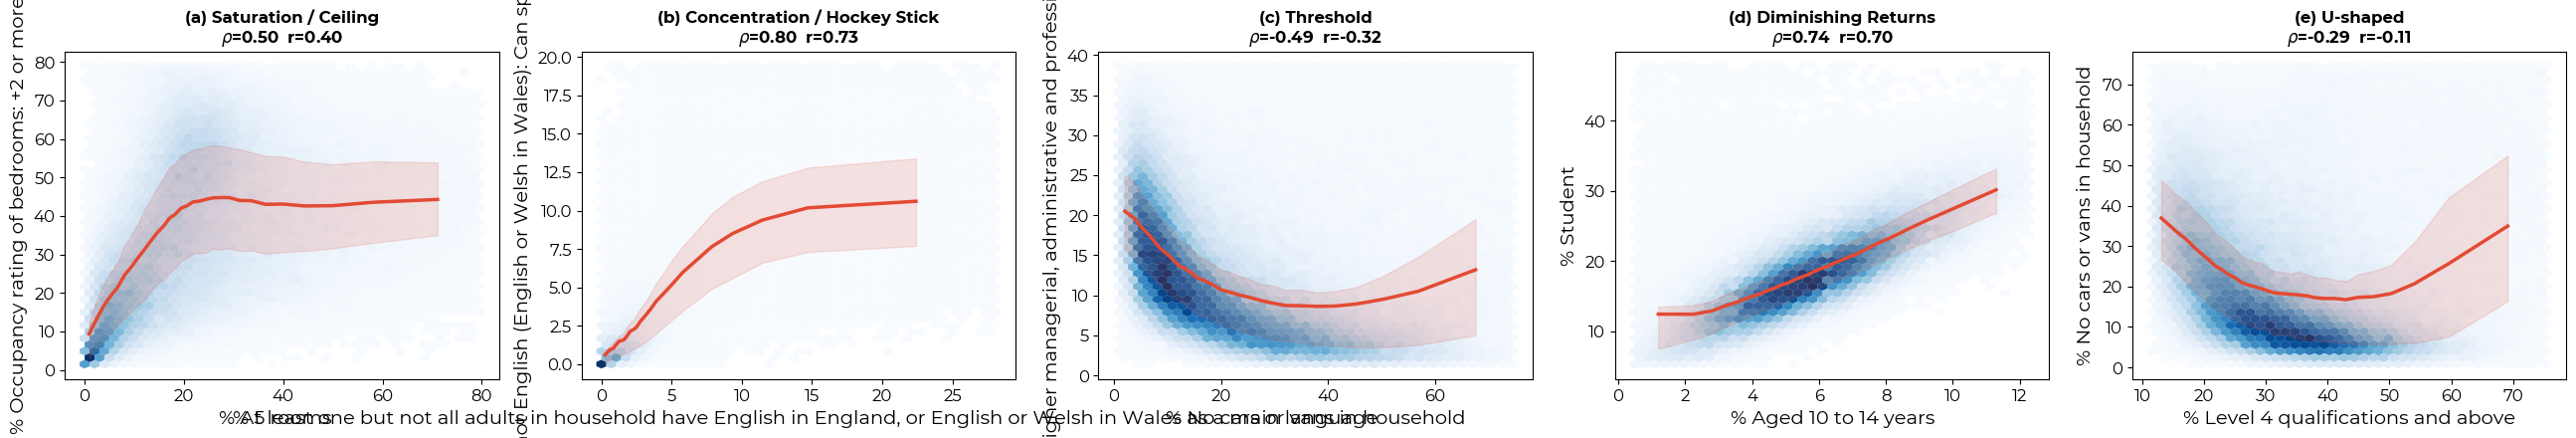

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))

for i, (v1, v2, title, xlabel, ylabel) in enumerate(nonlinearity_types):
    ax = axes[i]
    x, y = df[v1].values, df[v2].values
    x_c, y_c = _clip(x, y)
    x_c, y_c = x_c * 100, y_c * 100

    ax.hexbin(x_c, y_c, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.1)

    centers, means, lo, hi = _binned_stats(x_c, y_c)
    ax.plot(centers, means, color='#e34a33', linewidth=2.5, zorder=5)
    ax.fill_between(centers, lo, hi, color='#e34a33', alpha=0.15, zorder=4)

    rho, _ = spearmanr(x_c, y_c)
    r, _ = pearsonr(x_c, y_c)
    ax.set_title(f'{title}\n$\\rho$={rho:.2f}  r={r:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(pct_label(v1), fontsize=14)
    ax.set_ylabel(pct_label(v2), fontsize=14)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f"{output_dir}/nonlinearity_types_hexbin.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## 7b. Non-Linearity Types — Binned Median

Same five non-linearity types as 7a, but using **binned medians** instead of binned means.

In [14]:
def _binned_median_stats(x, y, n_bins=30):
    """Quantile-binned medians and IQR."""
    bin_edges = np.unique(np.percentile(x, np.linspace(0, 100, n_bins + 1)))
    n = len(bin_edges) - 1
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(x, bin_edges) - 1, 0, n - 1)
    medians, q25, q75 = [], [], []
    for b in range(n):
        vals = y[idx == b]
        if len(vals) > 10:
            medians.append(np.median(vals))
            q25.append(np.percentile(vals, 25))
            q75.append(np.percentile(vals, 75))
        else:
            medians.append(np.nan); q25.append(np.nan); q75.append(np.nan)
    m, lo, hi = np.array(medians), np.array(q25), np.array(q75)
    ok = ~np.isnan(m)
    return centers[ok], m[ok], lo[ok], hi[ok]

### 7b.1 Hexbin + Binned Median

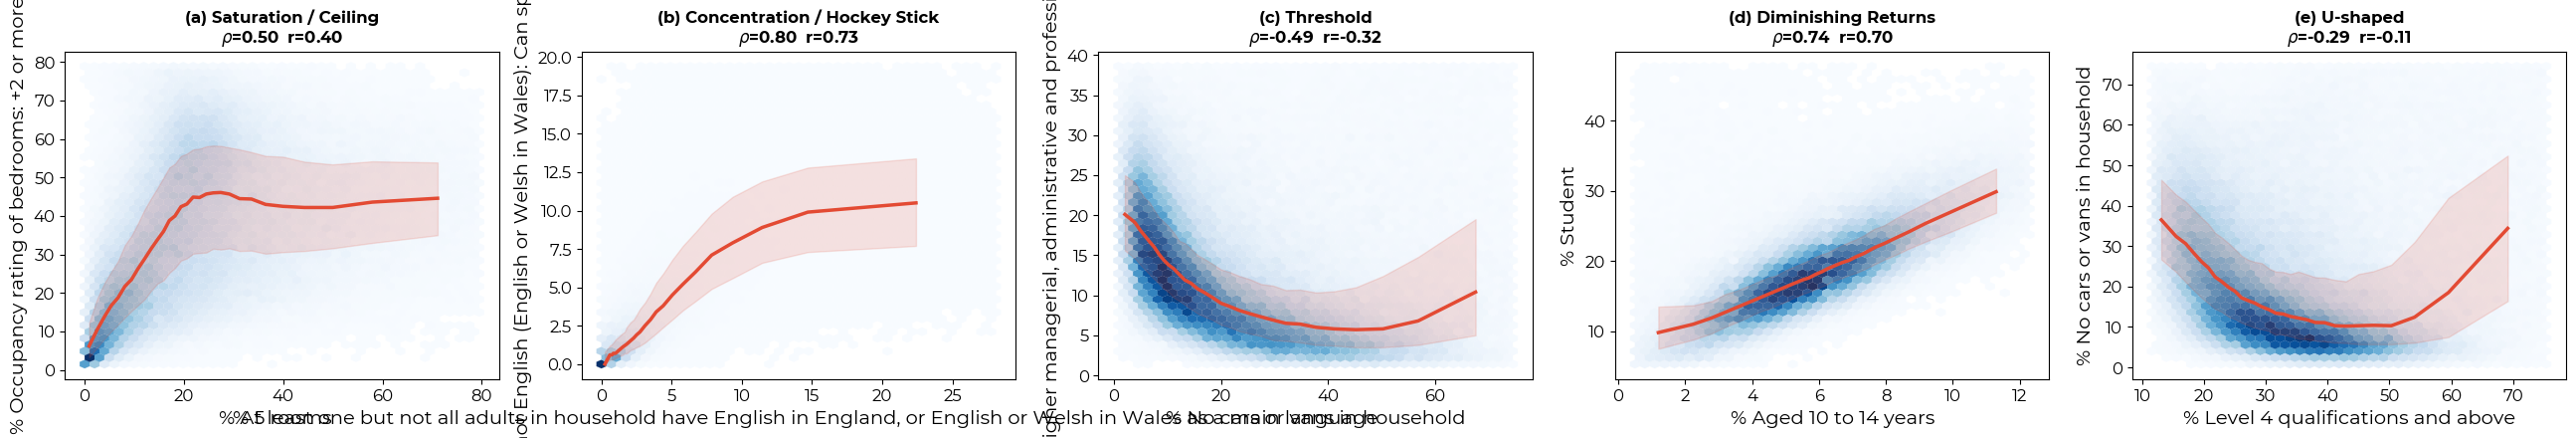

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))

for i, (v1, v2, title, xlabel, ylabel) in enumerate(nonlinearity_types):
    ax = axes[i]
    x, y = df[v1].values, df[v2].values
    x_c, y_c = _clip(x, y)
    x_c, y_c = x_c * 100, y_c * 100

    ax.hexbin(x_c, y_c, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.1)

    centers, medians, lo, hi = _binned_median_stats(x_c, y_c)
    ax.plot(centers, medians, color='#e34a33', linewidth=2.5, zorder=5)
    ax.fill_between(centers, lo, hi, color='#e34a33', alpha=0.15, zorder=4)

    rho, _ = spearmanr(x_c, y_c)
    r, _ = pearsonr(x_c, y_c)
    ax.set_title(f'{title}\n$\\rho$={rho:.2f}  r={r:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(pct_label(v1), fontsize=14)
    ax.set_ylabel(pct_label(v2), fontsize=14)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f"{output_dir}/nonlinearity_types_hexbin_median.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## 7c. Non-Linearity Types — Binned Most Probable Value (KDE Peak)

Same five non-linearity types, but using the **mode (KDE peak)** within each bin as the fitted line.

In [16]:
from scipy.stats import gaussian_kde as _gkde

def _binned_mpv_stats(x, y, n_bins=30):
    """Quantile-binned most probable value (KDE peak) and IQR."""
    bin_edges = np.unique(np.percentile(x, np.linspace(0, 100, n_bins + 1)))
    n = len(bin_edges) - 1
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(x, bin_edges) - 1, 0, n - 1)
    mpvs, q25, q75 = [], [], []
    for b in range(n):
        vals = y[idx == b]
        if len(vals) > 20:
            try:
                kde = _gkde(vals)
                y_grid = np.linspace(vals.min(), vals.max(), 200)
                mpvs.append(y_grid[np.argmax(kde(y_grid))])
            except Exception:
                mpvs.append(np.nan)
            q25.append(np.percentile(vals, 25))
            q75.append(np.percentile(vals, 75))
        else:
            mpvs.append(np.nan); q25.append(np.nan); q75.append(np.nan)
    m, lo, hi = np.array(mpvs), np.array(q25), np.array(q75)
    ok = ~np.isnan(m)
    return centers[ok], m[ok], lo[ok], hi[ok]

### 7c.1 Hexbin + Binned MPV

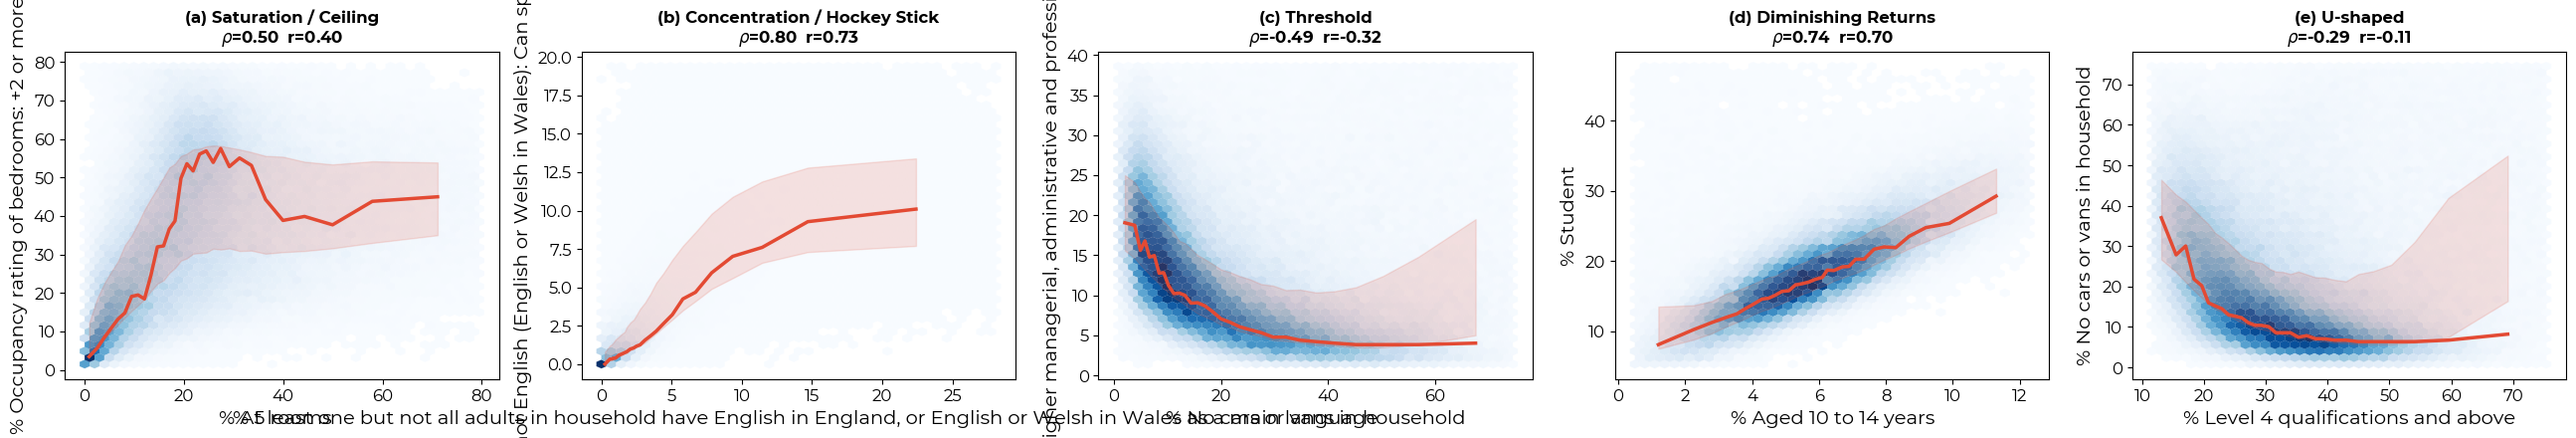

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))

for i, (v1, v2, title, xlabel, ylabel) in enumerate(nonlinearity_types):
    ax = axes[i]
    x, y = df[v1].values, df[v2].values
    x_c, y_c = _clip(x, y)
    x_c, y_c = x_c * 100, y_c * 100

    ax.hexbin(x_c, y_c, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.1)

    centers, mpvs, lo, hi = _binned_mpv_stats(x_c, y_c)
    ax.plot(centers, mpvs, color='#e34a33', linewidth=2.5, zorder=5)
    ax.fill_between(centers, lo, hi, color='#e34a33', alpha=0.15, zorder=4)

    rho, _ = spearmanr(x_c, y_c)
    r, _ = pearsonr(x_c, y_c)
    ax.set_title(f'{title}\n$\\rho$={rho:.2f}  r={r:.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(pct_label(v1), fontsize=14)
    ax.set_ylabel(pct_label(v2), fontsize=14)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f"{output_dir}/nonlinearity_types_hexbin_mpv.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Summary: Correlation Structure of Census Data

Clustered Spearman correlation heatmap with inset showing distribution of pairwise correlations.

In [18]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Compute Spearman correlation matrix
spearman_corr = df.corr(method='spearman')

# Hierarchical clustering to reorder variables
dist_matrix = 1 - np.abs(spearman_corr.values)
np.fill_diagonal(dist_matrix, 0)
# Make symmetric and fix any floating point issues
dist_matrix = (dist_matrix + dist_matrix.T) / 2
dist_matrix = np.clip(dist_matrix, 0, None)
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='ward')
order = leaves_list(Z)

# Reorder correlation matrix
corr_ordered = spearman_corr.values[np.ix_(order, order)]
ordered_vars = spearman_corr.columns[order]

# Category colour mapping for axis bars
unique_cats = sorted(set(var_to_category.values()))
cat_cmap = plt.cm.get_cmap('tab20', len(unique_cats))
cat_to_colour = {cat: cat_cmap(i) for i, cat in enumerate(unique_cats)}
cat_colours = [cat_to_colour[var_to_category.get(v, 'Unknown')] for v in ordered_vars]

# --- Figure layout: heatmap + category bar + inset histogram ---
fig = plt.figure(figsize=(10, 9))

# Category colour bar (top)
ax_cat_top = fig.add_axes([0.12, 0.88, 0.72, 0.02])
for j, c in enumerate(cat_colours):
    ax_cat_top.axvspan(j, j+1, color=c)
ax_cat_top.set_xlim(0, len(cat_colours))
ax_cat_top.set_xticks([])
ax_cat_top.set_yticks([])

# Category colour bar (left)
ax_cat_left = fig.add_axes([0.09, 0.12, 0.02, 0.75])
for j, c in enumerate(cat_colours):
    ax_cat_left.axhspan(j, j+1, color=c)
ax_cat_left.set_ylim(0, len(cat_colours))
ax_cat_left.set_xticks([])
ax_cat_left.set_yticks([])

# Main heatmap
ax_heat = fig.add_axes([0.12, 0.12, 0.72, 0.75])
im = ax_heat.imshow(corr_ordered, cmap='RdBu_r', vmin=-1, vmax=1,
                    aspect='auto', interpolation='nearest')
ax_heat.set_xticks([])
ax_heat.set_yticks([])
ax_heat.set_xlabel(f'{len(df.columns)} census variables (clustered)', fontsize=14)
ax_heat.set_ylabel(f'{len(df.columns)} census variables (clustered)', fontsize=14)

# Colourbar
ax_cb = fig.add_axes([0.86, 0.12, 0.02, 0.75])
cb = plt.colorbar(im, cax=ax_cb)
cb.set_label('Spearman correlation', fontsize=12)
cb.ax.tick_params(labelsize=11)

# Inset: histogram of pairwise correlations
ax_inset = fig.add_axes([0.18, 0.55, 0.25, 0.2])
upper_tri = spearman_corr.values[np.triu_indices(len(spearman_corr), k=1)]
ax_inset.hist(upper_tri, bins=80, color='#4878cf', alpha=0.85, edgecolor='none')
ax_inset.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax_inset.set_xlabel('Spearman r', fontsize=11)
ax_inset.set_ylabel('Pairs', fontsize=11)
ax_inset.tick_params(labelsize=9)
ax_inset.set_facecolor('white')
ax_inset.patch.set_alpha(0.85)
for spine in ax_inset.spines.values():
    spine.set_edgecolor('grey')
    spine.set_linewidth(0.8)

# Category legend
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=cat_to_colour[c], label=c) for c in unique_cats]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.savefig(f"{output_dir}/correlation_structure_summary.png", dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

print(f'Variables: {len(df.columns)}')
print(f'Output Areas: {len(df):,}')
print(f'Pairwise correlations: {len(upper_tri):,}')
print(f'Mean |Spearman|: {np.abs(upper_tri).mean():.3f}')
print(f'Pairs with |r| > 0.3: {(np.abs(upper_tri) > 0.3).sum():,} ({(np.abs(upper_tri) > 0.3).mean():.1%})')

ValueError: Distance matrix 'X' must be symmetric.

## 8b. Selected Non-Linear Relationships

Three examples of non-linear variable relationships.

In [ ]:
# Custom short y-axis labels
y_labels = {
    'ts0620002': '% Higher managerial & professional',
    'ts0500005': '% 4+ bedrooms',
    'ts0540003': '% Owns outright',
}

selected_pairs = [
    ('ts0050002', 'ts0620002'),  # % Europe vs % L1,L2,L3
    ('ts0450002', 'ts0500005'),  # % No cars vs % 4+ bedrooms
    ('ts0540003', 'ts0520003'),  # % Owns outright vs % Overcrowded
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (v1, v2) in enumerate(selected_pairs):
    ax = axes[i]
    x, y = df[v1].values, df[v2].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    x_c, y_c = _clip(x, y)
    x_c, y_c = x_c * 100, y_c * 100

    ax.hexbin(x_c, y_c, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.1)

    # Binned median
    n_bins = 30
    bin_edges = np.unique(np.percentile(x_c, np.linspace(0, 100, n_bins + 1)))
    n = len(bin_edges) - 1
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(x_c, bin_edges) - 1, 0, n - 1)
    medians, q25, q75 = [], [], []
    valid_c = []
    for b in range(n):
        vals = y_c[idx == b]
        if len(vals) > 10:
            medians.append(np.median(vals))
            q25.append(np.percentile(vals, 25))
            q75.append(np.percentile(vals, 75))
            valid_c.append(centers[b])
    ax.plot(valid_c, medians, color='#e34a33', linewidth=2.5, zorder=5, label='Binned median')
    ax.fill_between(valid_c, q25, q75, color='#e34a33', alpha=0.15, zorder=4)

    # Legend on left and right plots, no frame
    if i in (0, 2):
        ax.legend(fontsize=11, loc='best', frameon=False)

    ax.set_xlabel(pct_label(v1), fontsize=14)
    ax.set_ylabel(y_labels.get(v2, pct_label(v2)), fontsize=14)
    ax.tick_params(labelsize=12)

plt.tight_layout()
fig.savefig(f"{output_dir}/selected_nonlinear_hexbin_median.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

NameError: name 'plt' is not defined

## 9. Batch Export — All Candidate Pairs

Saves every candidate non-linear pair in all visualization styles to subfolders for browsing.

In [ ]:
from scipy.stats import gaussian_kde as _gkde_batch

batch_dir = f"{output_dir}/batch_export"
for sub in ['hexbin_mean', 'hexbin_median', 'hexbin_mpv']:
    os.makedirs(f"{batch_dir}/{sub}", exist_ok=True)

def _clip_batch(x, y, lo=1, hi=99):
    xlo, xhi = np.percentile(x, [lo, hi])
    ylo, yhi = np.percentile(y, [lo, hi])
    mask = (x >= xlo) & (x <= xhi) & (y >= ylo) & (y <= yhi)
    return x[mask], y[mask]

def _binned(x, y, n_bins=30, agg='mean'):
    bin_edges = np.unique(np.percentile(x, np.linspace(0, 100, n_bins + 1)))
    n = len(bin_edges) - 1
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    idx = np.clip(np.digitize(x, bin_edges) - 1, 0, n - 1)
    vals_out, q25, q75 = [], [], []
    for b in range(n):
        v = y[idx == b]
        if len(v) > 10:
            if agg == 'mean':
                vals_out.append(v.mean())
            elif agg == 'median':
                vals_out.append(np.median(v))
            elif agg == 'mpv':
                try:
                    kde = _gkde_batch(v)
                    grid = np.linspace(v.min(), v.max(), 200)
                    vals_out.append(grid[np.argmax(kde(grid))])
                except:
                    vals_out.append(np.nan)
            q25.append(np.percentile(v, 25))
            q75.append(np.percentile(v, 75))
        else:
            vals_out.append(np.nan); q25.append(np.nan); q75.append(np.nan)
    m, lo, hi = np.array(vals_out), np.array(q25), np.array(q75)
    ok = ~np.isnan(m)
    return centers[ok], m[ok], lo[ok], hi[ok]

pairs = list(nonlinear_candidates[['var1', 'var2']].itertuples(index=False))
n_pairs = len(pairs)
print(f"Exporting {n_pairs} pairs x 9 styles = {n_pairs * 9} plots...")

for pi, (v1, v2) in enumerate(pairs):
    x, y = df[v1].values, df[v2].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    x_c, y_c = _clip_batch(x, y)
    x_c, y_c = x_c * 100, y_c * 100

    cat1 = var_to_category.get(v1, v1)
    cat2 = var_to_category.get(v2, v2)
    safe_name = f"{pi:03d}_{v1}_vs_{v2}"

    for agg in ['mean', 'median', 'mpv']:
        centers, fitted, lo, hi = _binned(x_c, y_c, agg=agg)

        # --- Hexbin ---
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.hexbin(x_c, y_c, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.1)
        ax.plot(centers, fitted, color='#e34a33', linewidth=2.5, zorder=5)
        ax.fill_between(centers, lo, hi, color='#e34a33', alpha=0.15, zorder=4)
        ax.set_title(f'{cat1}\nvs {cat2}', fontsize=11, fontweight='bold')
        ax.set_xlabel(pct_label(v1), fontsize=14)
        ax.set_ylabel(pct_label(v2), fontsize=14)
        fig.savefig(f"{batch_dir}/hexbin_{agg}/{safe_name}.png", dpi=150, bbox_inches='tight', transparent=True)
        plt.close(fig)

    if (pi + 1) % 10 == 0:
        print(f"  {pi + 1}/{n_pairs} done")

print(f"\nDone! All plots saved to {batch_dir}/")
print("Subfolders: hexbin_mean, hexbin_median, hexbin_mpv")

Exporting 365 pairs x 9 styles = 3285 plots...
  10/365 done
  20/365 done
  30/365 done
  40/365 done


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


  50/365 done
